In [105]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay
from sklearn.mixture import GaussianMixture
import seaborn as sns


# Task 1

We begin by loading the necessary data. A function is created to read the labels (vowels) and features, storing them in a dictionary. Finally, we split the data into training and test sets.

In [106]:
def load_vowel_data(filename):
    vowel_data = {}

    with open(filename, "r") as file:
        for line in file:
            parts = line.split()
            label = parts[0][-2:]  #extrct vocal, for example in m01ae is ae the vocal. The last two is always the vocal
            features = parts[2:5]  # the features are the 3rd to 6th element in the line 
            features = [int(f) for f in features]  # convert to float
            if label not in vowel_data:
                vowel_data[label] = []
            vowel_data[label].append(features)

    
    for vowel in vowel_data:
        vowel_data[vowel] = np.array(vowel_data[vowel])
    
    return vowel_data

# load data from file
filename = 'Data/Iris_TTT4275/vowdata_nohead.dat'
vowel_data = load_vowel_data(filename)

# Splitt into trainingset (first 70 samples) og testset (last 69 samples)
train_data = {vowel: data[:70] for vowel, data in vowel_data.items()}
test_data = {vowel: data[70:] for vowel, data in vowel_data.items()}



Then we will find the mean value for each feature for each class and full covariance matrix for each class

In [107]:
# function to compute mean value and covariance matrix
def compute_mean_covariance(data):
    mean_vectors = {}
    covariance_matrices = {}

    for vowel, samples in data.items():
        mean_vectors[vowel] = np.mean(samples, axis=0)  # find mean for each vowel and store in mean_vectores
        covariance_matrices[vowel] = np.cov(samples, rowvar=False)  # find covariance matrix for each vowel
    return mean_vectors, covariance_matrices

# Use the function above to find mean value and covarance matrix for each vowel in training set
mean_vectors, covariance_matrices = compute_mean_covariance(train_data)

#  Remove comment to print mean and covariance for each vowel
#for vowel in mean_vectors:
    #print(f"\nVokal: {vowel}")
    #print(f"Middelverdi: {mean_vectors[vowel]}")
    #print(f"Kovariansmatrise:\n{covariance_matrices[vowel]}")



Function to classify a sample with a single Gaussian class model.

The classification is based on Gaussian density: 

$$
p(x / \omega_i) = N(\mu_i, \Sigma_i) = \frac{1}{\sqrt{(2\pi)^D |\Sigma_i|}} \exp \left[ -\frac{1}{2} (x - \mu_i)^T \Sigma_i^{-1} (x - \mu_i) \right], \quad i = 1, \dots, C
$$

For each sample, we calculate the probability that it belongs to a certain class and assign it to the class with the highest likelihood.


In [108]:
def classify_sample(x, mean_vectors, cov_matrices):
    best_class = None   # Our goal is to find the best class, this will be updated if probability of this class is better than all the earlier classes
    max_prob = -np.inf  #set as low as possible, updates later. 
    
    for vowel, mean in mean_vectors.items():
        cov = cov_matrices[vowel] 
        det_cov = np.linalg.det(cov)
        cov_inv = np.linalg.inv(cov)
        
        #PDF
        diff = x - mean
        exponent = -0.5 * np.dot(diff.T, np.dot(cov_inv, diff))
        prob = np.exp(exponent) / np.sqrt((2 * np.pi) ** 3 * det_cov) 

        if prob > max_prob:
            max_prob = prob
            best_class = vowel

    return best_class


Than we use the classifier on the samples in test data and compute the error rate and plot confusionmatrix.

Error rate: 34.18%


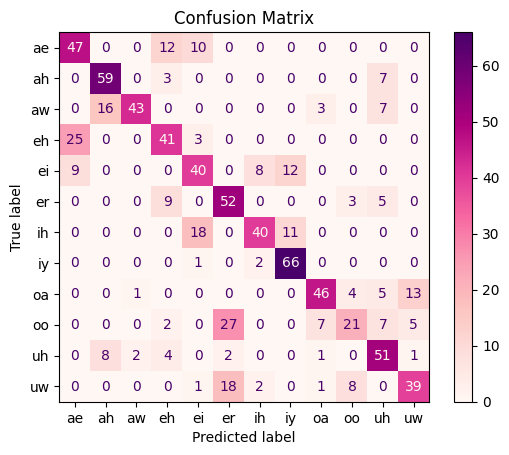

In [109]:
true_labels = []
predicted_labels = []

for vowel, samples in test_data.items():
    for sample in samples:
        predicted_vowel = classify_sample(sample, mean_vectors, covariance_matrices)
        true_labels.append(vowel)
        predicted_labels.append(predicted_vowel)
        
# Make confusion matrix and error rate to analyse the clasifier
conf_matrix = confusion_matrix(true_labels, predicted_labels, labels=list(vowel_data.keys()))
error_rate = 1 - accuracy_score(true_labels, predicted_labels)

# Uses ConfusionMatrixDisplay to visualize the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=vowel_data.keys())
disp.plot(cmap="RdPu")  # Fungerer i Blues også
plt.title("Confusion Matrix")
print(f"Error rate: {error_rate*100:.2f}%")
plt.show()

Make diagonal covariance matrix by multiplying with the identity matrix

In [110]:
diag_cov_matrices = {}

for vowel in mean_vectors:
    identity_matrix = np.identity(3)
    diag_cov_matrices[vowel] = covariance_matrices[vowel]*identity_matrix
    #print(f'Diagonal matrix for {vowel}:\n {diag_cov_matrices[vowel]}\n ') #remove comment to print diagonal covariance matrix for each vowel



Classify the samples with diagonal covariance matrix. Than make confusion matrix and error rate.

Error rate: 53.86%


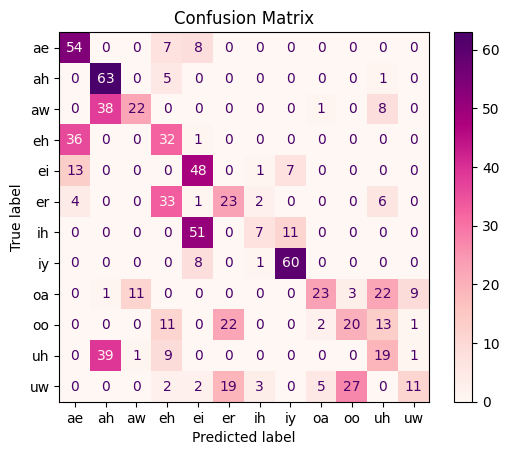

In [111]:
predicted_labels_diag = []

for vowel, samples in test_data.items():
    for sample in samples:
        predicted_vowel = classify_sample(sample, mean_vectors, diag_cov_matrices)
        predicted_labels_diag.append(predicted_vowel)

conf_matrix_diag = confusion_matrix(true_labels, predicted_labels_diag, labels=list(vowel_data.keys()))
error_rate_diag = 1 - accuracy_score(true_labels, predicted_labels_diag)

# Using ConfusionMatrixDisplay to visualize the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_diag, display_labels=test_data.keys())
disp.plot(cmap="RdPu") 
plt.title("Confusion Matrix")
print(f"Error rate: {error_rate_diag*100:.2f}%")
plt.show()

# Task 2

Function to train GMM models using diagonal covariance matrices

In [112]:
def train_gmm_models(train_data, n_components):
    gmm_models = {}
    
    for vowel, samples in train_data.items():
        gmm = GaussianMixture(n_components=n_components, covariance_type='diag', random_state=42)
        gmm.fit(samples)
        gmm_models[vowel] = gmm
    
    return gmm_models 

Function to classify a sample with the GMM model

In [113]:
def classify_sample_gmm(sample, gmm_models):
    max_log_likelihood = -np.inf 
    best_class = None 
    
    for vowel, gmm in gmm_models.items():
        log_likelihood = gmm.score_samples(sample.reshape(1, -1))[0]
        
        if log_likelihood > max_log_likelihood:
            max_log_likelihood = log_likelihood
            best_class = vowel
    
    return best_class

Functon that can be used on GMMs that compute confusion matrix and error rate. 

In [114]:
def evaluate_classifier(test_data, gmm_models):
    true_labels = []
    predicted_labels = []
    
    for vowel, samples in test_data.items():
        for sample in samples:
            predicted_vowel = classify_sample_gmm(sample, gmm_models)
            true_labels.append(vowel)
            predicted_labels.append(predicted_vowel)
    
    conf_matrix = confusion_matrix(true_labels, predicted_labels, labels=list(test_data.keys()))
    error_rate = 1 - accuracy_score(true_labels, predicted_labels)
    
    return conf_matrix, error_rate


Eroor rate: 37.80


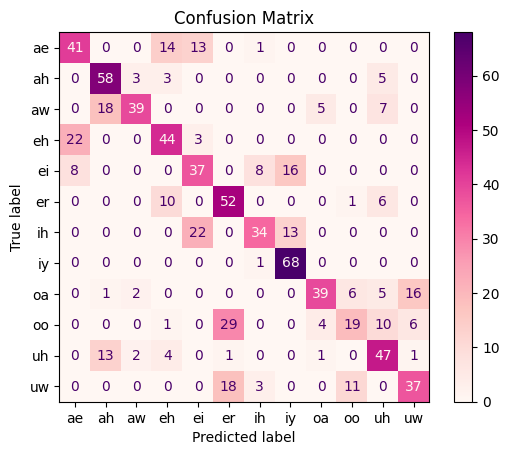

Error rate: 36.23


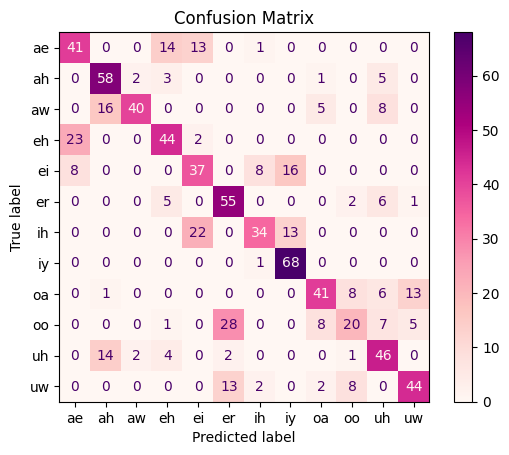

In [115]:

# Train GMM models (for 2 and 3)
gmm_models_2 = train_gmm_models(train_data, n_components=2)
gmm_models_3 = train_gmm_models(train_data, n_components=3)

# Evaluate classifiers
conf_matrix_2, error_rate_2 = evaluate_classifier(test_data, gmm_models_2)
conf_matrix_3, error_rate_3 = evaluate_classifier(test_data, gmm_models_3)

print(f"Eroor rate: {error_rate_2*100:.2f}")

disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_2, display_labels=test_data.keys())
disp.plot(cmap="RdPu")  
plt.title("Confusion Matrix")
plt.show()

print(f'Error rate: {error_rate_3*100:.2f}')

disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_3, display_labels=test_data.keys())
disp.plot(cmap="RdPu") 
plt.title("Confusion Matrix")
plt.show()


Histogram of vowel "oo" and "er" for training data


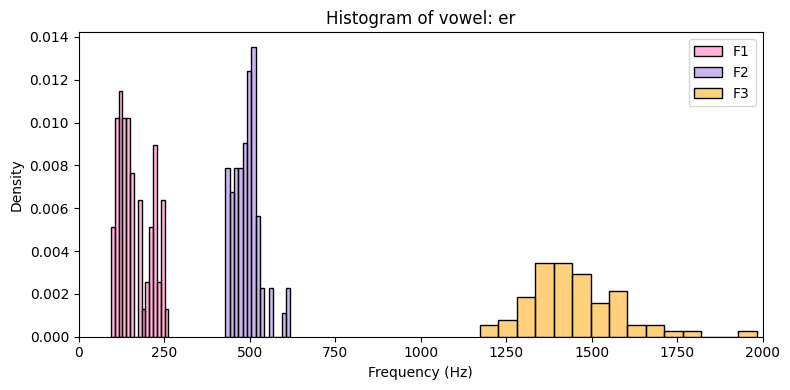

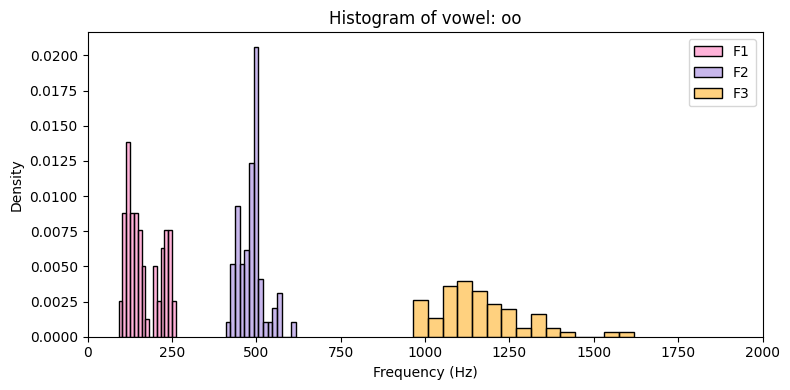

Histogram of vowel "oo" and "er" for test data


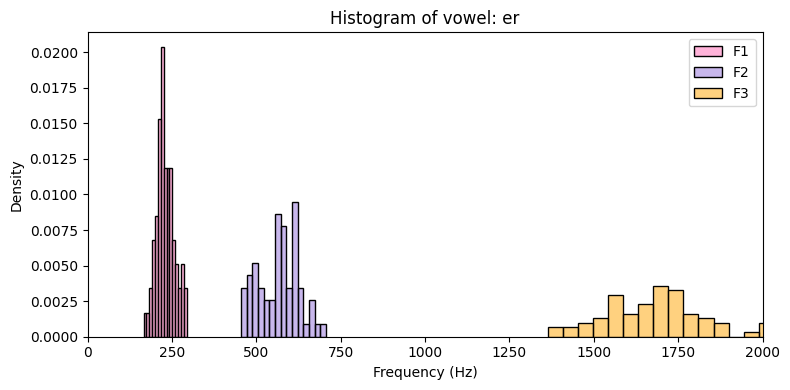

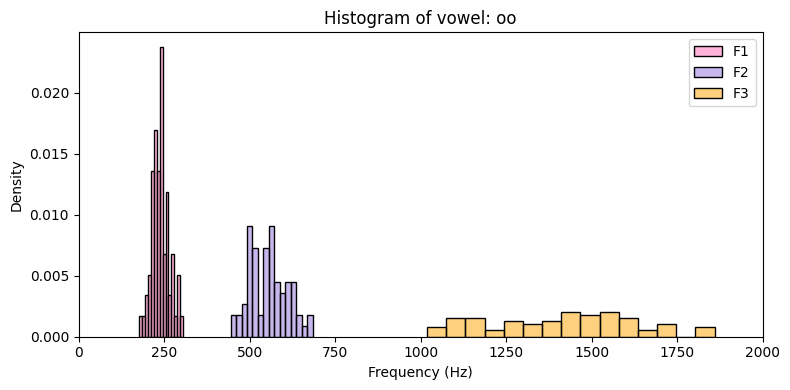

In [116]:
def print_vowel_histograms(train_data, selected_vowels):
    colors = {
        'F1': 'hotpink',
        'F2': 'mediumpurple',
        'F3': 'orange'
    }  
    
    for vowel in selected_vowels & train_data.keys():
        formant_values = np.array(train_data[vowel])
        formant_data = {"F1": formant_values[:, 0], "F2": formant_values[:, 1], "F3": formant_values[:, 2]}

        plt.figure(figsize=(8, 4))
        for formant, values in formant_data.items():
            sns.histplot(values, bins=15, color=colors[formant], stat="density", alpha=0.5, label=formant)

        plt.title(f'Histogram of vowel: {vowel}')
        plt.xlabel('Frequency (Hz)')
        plt.ylabel('Density')
        plt.xlim(0, 2000)
        plt.legend()
        plt.tight_layout()
        plt.show()

# Print histograms for selected vowels
print('Histogram of vowel "oo" and "er" for training data')
print_vowel_histograms(train_data, {"oo", "er"})
print('Histogram of vowel "oo" and "er" for test data')
print_vowel_histograms(test_data, {"oo", "er"})
